In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Identifying the file structure of thedataset

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/mlx-2-0-regression/sample_submission.csv
/kaggle/input/competitions/mlx-2-0-regression/train.csv
/kaggle/input/competitions/mlx-2-0-regression/test.csv


# Identifying the features and labels in the dataset

In [ ]:
train_df = pd.read_csv("./data/train.csv") # Loading the train dataset
test_df = pd.read_csv("./data/test.csv") # Loading the test dataset
train_df.head()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,...,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
0,76339,0.482850,1.169231,80.018,0.0201,Country Stuff (feat. Jake Owen),1.0,0.789,154586.0,NaN,...,4.0,161853.0,7.0,4.0,NaN,0.607,7.0,0.7250,0.000000,74
1,80006,0.267862,1.321321,147.966,0.3340,Solitude,6.0,0.715,46874.0,15.0,...,4.0,155619.0,1.0,4.0,0.843,0.783,4.0,NaN,0.043200,2
2,83501,0.242606,1.285319,142.980,0.1110,BDFFRNT (Saved from Conformity),4.0,NaN,264665.0,7.0,...,4.0,209378.0,6.0,4.0,NaN,0.211,10.0,0.6020,0.000000,35
3,81530,0.426400,1.279435,123.063,0.1960,Headlights (feat. Ilsey),5.0,0.685,209208.0,5.0,...,4.0,219043.0,11.0,4.0,0.702,0.369,NaN,0.8200,0.000335,70
4,60534,0.000000,0.974906,132.722,0.0811,Afraid,6.0,0.856,215346.0,5.0,...,4.0,258893.0,1.0,0.0,0.000,0.631,1.0,0.0221,0.000000,78


## Identifying the columns in the dataset

In [4]:
print("Columns in the Dataset: ")
print(train_df.columns)
print(f"There are {len(train_df.columns)} number of columns in this dataset")


Columns in the Dataset: 
Index(['id', 'emotional_charge_2', 'groove_efficiency_1', 'beat_frequency_1',
       'organic_texture_2', 'composition_label_0', 'harmonic_scale_1',
       'intensity_index_0', 'duration_ms_0', 'album_name_length',
       'beat_frequency_0', 'beat_frequency_2', 'artist_count',
       'composition_label_1', 'publication_timestamp', 'weekday_of_release',
       'album_component_count', 'emotional_charge_1', 'emotional_charge_0',
       'tonal_mode_2', 'key_variety', 'performance_authenticity_2',
       'performance_authenticity_0', 'season_of_release', 'time_signature_1',
       'duration_ms_2', 'lunar_phase', 'instrumental_density_2',
       'organic_texture_0', 'creator_collective', 'vocal_presence_2',
       'tonal_mode_1', 'vocal_presence_1', 'vocal_presence_0',
       'intensity_index_1', 'organic_immersion_0', 'tonal_mode_0',
       'groove_efficiency_2', 'instrumental_density_1', 'organic_immersion_2',
       'duration_consistency', 'composition_label_2', 

In this dataset there are 62 columns. And according to the columns there are 61 features and 1 label called 'target'. Now, we have to identify the NaN value records in this dataset

# Data Preprocessing

## Droping the duplicate values in the dataset

In [5]:
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

## Identifying how many record have NaN values

In [6]:
print(f"There are {len(train_df)} number of records in the train dataset")
nan_value_records = train_df[train_df.isna().any(axis=1)]
print(f"There are {len(nan_value_records)} number of records with NaN values")

print("\n")

print(f"There are {len(test_df)} number of records in the test dataset")
nan_records_test = test_df[test_df.isna().any(axis=1)]
print(f"There are {len(nan_records_test)} number of records with NaN values")


There are 61609 number of records in the train dataset
There are 59828 number of records with NaN values


There are 41074 number of records in the test dataset
There are 39864 number of records with NaN values


## Identifying Columns with NaN values

In [7]:
nan_value_columns = train_df.columns[train_df.isna().any()]
print(nan_value_columns)
print(f"There are {len(nan_value_columns)} columns that has NaN values")

Index(['emotional_charge_2', 'groove_efficiency_1', 'beat_frequency_1',
       'organic_texture_2', 'composition_label_0', 'harmonic_scale_1',
       'intensity_index_0', 'duration_ms_0', 'album_name_length',
       'beat_frequency_0', 'beat_frequency_2', 'artist_count',
       'composition_label_1', 'publication_timestamp', 'weekday_of_release',
       'album_component_count', 'emotional_charge_1', 'emotional_charge_0',
       'tonal_mode_2', 'key_variety', 'performance_authenticity_2',
       'performance_authenticity_0', 'season_of_release', 'time_signature_1',
       'duration_ms_2', 'lunar_phase', 'instrumental_density_2',
       'organic_texture_0', 'creator_collective', 'vocal_presence_2',
       'tonal_mode_1', 'vocal_presence_1', 'vocal_presence_0',
       'intensity_index_1', 'organic_immersion_0', 'tonal_mode_0',
       'groove_efficiency_2', 'instrumental_density_1', 'organic_immersion_2',
       'duration_consistency', 'composition_label_2', 'organic_texture_1',
       'rh

According to the this dataset has NaN values in every column other than "Id" and "target" columns.

## Geting the description of the dataset

In [8]:
train_df.describe()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,beat_frequency_0,...,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
count,61609.000000,59167.000000,61429.000000,61223.000000,61226.000000,58304.000000,55638.000000,6.032000e+04,52015.000000,51878.000000,...,59704.000000,5.250400e+04,53925.000000,58455.000000,56049.000000,60063.000000,57142.000000,60916.000000,60900.000000,61609.000000
mean,51390.780162,0.316976,1.238856,121.022910,0.274748,5.192594,0.604426,2.011315e+05,18.225723,119.133973,...,3.874849,2.110477e+05,5.212499,3.901274,0.612252,0.458851,5.288894,0.616045,0.148391,52.067328
std,29659.344472,0.212777,6.171617,30.467061,0.303020,3.629153,0.243943,1.100738e+05,14.404713,32.067971,...,0.564558,8.911099e+04,3.571288,0.465295,0.179591,0.261196,3.567118,0.230109,0.306915,21.569248
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.485000e+03,1.000000,0.000000,...,0.000000,4.120000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25832.000000,0.143877,0.730914,96.138000,0.027125,2.000000,0.447000,1.482340e+05,9.000000,94.802250,...,4.000000,1.682000e+05,2.000000,4.000000,0.506000,0.243000,2.000000,0.477000,0.000000,37.000000
50%,51410.000000,0.291060,1.004894,120.012000,0.141000,5.000000,0.633000,1.959215e+05,14.000000,119.893000,...,4.000000,2.029730e+05,5.000000,4.000000,0.630000,0.449000,5.000000,0.646000,0.000019,57.000000
75%,77069.000000,0.466860,1.358251,141.401000,0.454000,8.000000,0.803000,2.402488e+05,23.000000,140.023000,...,4.000000,2.413605e+05,8.000000,4.000000,0.745000,0.663000,8.000000,0.791000,0.024600,69.000000
max,102681.000000,0.976063,654.000000,239.983000,0.996000,11.000000,1.000000,3.664274e+06,199.000000,235.998000,...,5.000000,3.550973e+06,11.000000,5.000000,0.979000,1.000000,11.000000,1.000000,1.000000,100.000000


In [9]:
test_df.describe()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,beat_frequency_0,...,emotional_resonance_2,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0
count,41074.000000,39477.000000,40973.000000,40795.000000,40846.000000,38851.000000,37084.000000,4.024400e+04,34818.000000,34617.000000,...,37878.000000,39831.000000,3.487000e+04,36009.000000,38995.000000,37392.000000,40069.000000,38143.000000,40642.000000,40574.000000
mean,51266.332181,0.317621,1.361691,121.188746,0.273544,5.194744,0.603394,2.015330e+05,18.297145,119.093564,...,0.482031,3.873641,2.127539e+05,5.170041,3.904372,0.613224,0.458080,5.298849,0.616424,0.147817
std,29616.602490,0.212754,10.798167,30.748513,0.303162,3.634132,0.243186,1.214873e+05,14.392102,32.088262,...,0.250988,0.564785,1.166366e+05,3.555812,0.465687,0.178521,0.260893,3.572586,0.229218,0.306494
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.391000e+03,1.000000,0.000000,...,0.000000,0.000000,4.120000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25441.500000,0.144666,0.730178,96.228500,0.027400,2.000000,0.449000,1.482500e+05,9.000000,94.646000,...,0.288000,4.000000,1.682965e+05,2.000000,4.000000,0.506000,0.242000,2.000000,0.479000,0.000000
50%,51244.000000,0.291669,1.005917,120.022000,0.139000,5.000000,0.633000,1.950930e+05,14.000000,119.659000,...,0.478000,4.000000,2.031730e+05,5.000000,4.000000,0.632000,0.446000,5.000000,0.648000,0.000019
75%,76910.000000,0.467372,1.356303,141.964500,0.449000,8.000000,0.800000,2.400000e+05,23.000000,140.037000,...,0.676000,4.000000,2.417662e+05,8.000000,4.000000,0.746000,0.664000,8.000000,0.790000,0.025700
max,102682.000000,0.952567,1000.000000,248.500000,0.996000,11.000000,1.000000,4.449616e+06,238.000000,239.713000,...,1.000000,5.000000,7.054236e+06,11.000000,5.000000,0.978000,0.998000,11.000000,1.000000,1.000000


Let's next identify the numerical and categrical values in the dataset.
Since there is too many records with NaN values let's replace them with,

**Numerical Values -> Mean**

**Categorical Values -> Mode**

## Identifying the Numerical Values and Categorical Columns in the dataset

In [10]:
#Identyfying the numerical and categorical columns in the dataset
num_cols = train_df.select_dtypes(include="number").columns.drop("target")
cat_cols = train_df.select_dtypes(include="object").columns.tolist()

print("Columns with Numerical Values: ")
print(num_cols)

print("Columns with Categorical Values: ")
print(cat_cols)

Columns with Numerical Values: 
Index(['id', 'emotional_charge_2', 'groove_efficiency_1', 'beat_frequency_1',
       'organic_texture_2', 'harmonic_scale_1', 'intensity_index_0',
       'duration_ms_0', 'album_name_length', 'beat_frequency_0',
       'beat_frequency_2', 'artist_count', 'album_component_count',
       'emotional_charge_1', 'emotional_charge_0', 'tonal_mode_2',
       'key_variety', 'performance_authenticity_2',
       'performance_authenticity_0', 'time_signature_1', 'duration_ms_2',
       'instrumental_density_2', 'organic_texture_0', 'vocal_presence_2',
       'tonal_mode_1', 'vocal_presence_1', 'vocal_presence_0',
       'intensity_index_1', 'organic_immersion_0', 'tonal_mode_0',
       'groove_efficiency_2', 'instrumental_density_1', 'organic_immersion_2',
       'duration_consistency', 'organic_texture_1', 'rhythmic_cohesion_0',
       'emotional_resonance_1', 'rhythmic_cohesion_1',
       'performance_authenticity_1', 'tempo_volatility', 'organic_immersion_1',
  

## Replacing the missing numerical values with mean values

In [11]:
means = pd.concat([train_df[num_cols],test_df[num_cols]],axis=0).mean()

train_df[num_cols] = train_df[num_cols].fillna(means)
test_df[num_cols] = test_df[num_cols].fillna(means)

## Replace the missing weekday_of_release using timestamp
For the weekday of release we can fill it using the public timestamp. Because we can find the weekday using the timestamp

In [12]:
print(len(train_df[train_df["publication_timestamp"].isna()]))

1508


In [13]:
train_df["publication_timestamp"] = pd.to_datetime(train_df["publication_timestamp"])
train_df["weekday_of_release"] = train_df["publication_timestamp"].dt.day_name()

test_df["publication_timestamp"] = pd.to_datetime(test_df["publication_timestamp"])
test_df["weekday_of_release"] = test_df["publication_timestamp"].dt.day_name()

## Replace the missing season_of_values using timestamp

In [14]:
season_map = {
    1: 'winter', 2: 'winter', 3: 'spring',
    4: 'spring', 5: 'spring', 6: 'summer',
    7: 'summer', 8: 'summer', 9: 'autumn',
    10: 'autumn', 11: 'autumn', 12: 'winter'
}

train_df['season_of_release'] = train_df['publication_timestamp'].dt.month.map(season_map)
test_df['season_of_release'] = test_df['publication_timestamp'].dt.month.map(season_map)

## Replacing the missing categorical values with mode values

In [15]:
for col in cat_cols:
    mode_value = pd.concat([train_df[col],test_df[col]], axis=0).mode()[0]
    train_df[col] = train_df[col].fillna(mode_value)
    test_df[col] = test_df[col].fillna(mode_value)

In [16]:
train_df.head()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,...,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
0,76339,0.482850,1.169231,80.018,0.0201,Country Stuff (feat. Jake Owen),1.0,0.789000,154586.0,18.254362,...,4.0,161853.0,7.0,4.0,0.612641,0.607,7.000000,0.725000,0.000000,74
1,80006,0.267862,1.321321,147.966,0.3340,Solitude,6.0,0.715000,46874.0,15.000000,...,4.0,155619.0,1.0,4.0,0.843000,0.783,4.000000,0.616197,0.043200,2
2,83501,0.242606,1.285319,142.980,0.1110,BDFFRNT (Saved from Conformity),4.0,0.604013,264665.0,7.000000,...,4.0,209378.0,6.0,4.0,0.612641,0.211,10.000000,0.602000,0.000000,35
3,81530,0.426400,1.279435,123.063,0.1960,Headlights (feat. Ilsey),5.0,0.685000,209208.0,5.000000,...,4.0,219043.0,11.0,4.0,0.702000,0.369,5.292879,0.820000,0.000335,70
4,60534,0.000000,0.974906,132.722,0.0811,Afraid,6.0,0.856000,215346.0,5.000000,...,4.0,258893.0,1.0,0.0,0.000000,0.631,1.000000,0.022100,0.000000,78


In [17]:
train_df[cat_cols].head()

,composition_label_0,composition_label_1,publication_timestamp,weekday_of_release,season_of_release,lunar_phase,creator_collective,composition_label_2,track_identifier
0,Country Stuff (feat. Jake Owen),Fancy Like,2021-06-04,Friday,summer,waning,"Walker Hayes,",Payday (feat. Young Thug),Certified Lover Boy
1,Solitude,TryHard,2019-07-01,Monday,summer,waning,"Zpvrt,",WontYouSaveMe,BornTo DieAlone
2,BDFFRNT (Saved from Conformity),Wow,2014-11-18,Tuesday,autumn,full,"Dillon Chase,",Payday (feat. Young Thug),BDFFRNT
3,Headlights (feat. Ilsey),Sugar (feat. Francesco Yates),2015-09-25,Friday,autumn,full,"Various Artists,",Heatwave (feat. Akon),Sugar
4,Afraid,Maneater,2006-01-01,Sunday,winter,waxing,"Nelly Furtado,",Promiscuous Interlude,Loose


In [18]:
print(train_df["composition_label_0"].nunique())
print(train_df["composition_label_1"].nunique())
print(train_df["creator_collective"].nunique())
print(train_df["composition_label_2"].nunique())
print(train_df["track_identifier"].nunique())

21709
22930
15139
22169
22991


It is not easy to find the similar values in those columns.

In [19]:
train_df["weekday_of_release"].unique()

array(['Friday', 'Monday', 'Tuesday', 'Sunday', 'Wednesday', 'Thursday',
       'Saturday'], dtype=object)

In [20]:
train_df["season_of_release"].unique()

array(['summer', 'autumn', 'winter', 'spring'], dtype=object)

In [21]:
train_df["lunar_phase"].unique()

array(['waning', 'full', 'waxing', 'new'], dtype=object)

## Encoding the weekday_of_release column

In [22]:
weekday_map = {
    "Monday":0,
    "Tuesday":1,
    "Wednesday":2,
    "Thursday":3,
    "Friday":4,
    "Saturday":5,
    "Sunday":6
}

train_df["weekday_of_release_encoded"] = train_df["weekday_of_release"].map(weekday_map)
test_df["weekday_of_release_encoded"] = test_df["weekday_of_release"].map(weekday_map)

## Encoding the season_of_release columns

In [23]:
season_map = {
    "spring":0,
    "summer":1,
    "autumn":2,
    "winter":3
}

train_df["season_of_release_encoded"] = train_df["season_of_release"].map(season_map)
test_df["season_of_release_encoded"] = test_df["season_of_release"].map(season_map)

## Encoding the lunar_phase column

In [24]:
lunarphase_map = {
    "new":0,
    "waxing":1,
    "full":2,
    "waning":3
}
train_df["lunar_phase_encoded"] = train_df["lunar_phase"].map(lunarphase_map)
test_df["lunar_phase_encoded"] = test_df["lunar_phase"].map(lunarphase_map)

## composition_label_0, composition_label_1, composition_label_2, creator_collective and track_identifier
In these features there are too many lables. Since there are too many labels. It is not suitable to use label encoding. There for we have to use frequency encoding to encode the categorical data.

In [25]:
features = ["composition_label_0","composition_label_1","composition_label_2","creator_collective","track_identifier"]

for feature in features:
    freq_map = pd.concat([train_df[feature],test_df[feature]],axis=0).value_counts(normalize=True)
    train_df[f"{feature}_encoded"] = train_df[feature].map(freq_map)
    test_df[f"{feature}_encoded"] = test_df[feature].map(freq_map).fillna(freq_map.mean())

# Feature Engineering

Since publication timestamp is a time stamp we have to break that into year, month and date

In [26]:
train_df["publication_year"] = train_df["publication_timestamp"].dt.year
train_df["publication_month"] = train_df["publication_timestamp"].dt.month
train_df["publication_day"] = train_df["publication_timestamp"].dt.day

test_df["publication_year"] = test_df["publication_timestamp"].dt.year
test_df["publication_month"] = test_df["publication_timestamp"].dt.month
test_df["publication_day"] = test_df["publication_timestamp"].dt.day

In [27]:
cols = ['tonal_mode_0', 'tonal_mode_1', 'tonal_mode_2']
#train_df['tonal_mode_mean'] = train_df[cols].mean(axis=1)
train_df['tonal_mode_std'] = train_df[cols].std(axis=1)

#test_df['tonal_mode_mean'] = train_df[cols].mean(axis=1)
test_df['tonal_mode_std'] = train_df[cols].std(axis=1)

In [28]:
#cols = ["emotional_charge_0", "emotional_charge_1", "emotional_charge_2"]
#train_df["emotional_charge_mean"] = train_df[cols].mean(axis=1)
#train_df["emotional_charge_std"] = train_df[cols].std(axis=1)
#train_df["emotional_charge_max"] = train_df[cols].max(axis=1)
#train_df["emotional_charge_min"] = train_df[cols].min(axis=1)

In [29]:
#train_df['duration_range'] = train_df[['duration_ms_0', 'duration_ms_1', 'duration_ms_2']].max(axis=1) - train_df[['duration_ms_0', 'duration_ms_1', 'duration_ms_2']].min(axis=1)

In [30]:
#train_df["beat_freq_mean"] = train_df[["beat_frequency_0","beat_frequency_1","beat_frequency_2"]].mean(axis=1)

In [31]:
train_df["intensity_consistency"] = train_df[["intensity_index_0","intensity_index_1","intensity_index_2"]].mean(axis=1)

test_df["intensity_consistency"] = test_df[["intensity_index_0","intensity_index_1","intensity_index_2"]].mean(axis=1)

In [32]:
train_df["overall_energy_0"] = (train_df["intensity_index_0"] +train_df["groove_efficiency_0"] +train_df["rhythmic_cohesion_0"]) / 3
train_df["overall_energy_1"] = (train_df["intensity_index_1"] +train_df["groove_efficiency_1"] +train_df["rhythmic_cohesion_1"]) / 3
train_df["overall_energy_2"] = (train_df["intensity_index_2"] +train_df["groove_efficiency_2"] +train_df["rhythmic_cohesion_2"]) / 3

test_df["overall_energy_0"] = (test_df["intensity_index_0"] +test_df["groove_efficiency_0"] +test_df["rhythmic_cohesion_0"]) / 3
test_df["overall_energy_1"] = (test_df["intensity_index_1"] +test_df["groove_efficiency_1"] +test_df["rhythmic_cohesion_1"]) / 3
test_df["overall_energy_2"] = (test_df["intensity_index_2"] +test_df["groove_efficiency_2"] +test_df["rhythmic_cohesion_2"]) / 3

In [33]:
train_df = train_df.drop(["id"] + cat_cols, axis=1)
test_ids = test_df['id']
test_df=test_df.drop(['id'],axis=1)
test_df=test_df.drop(cat_cols, axis=1)

# Correlation Analysis and Feature Selection

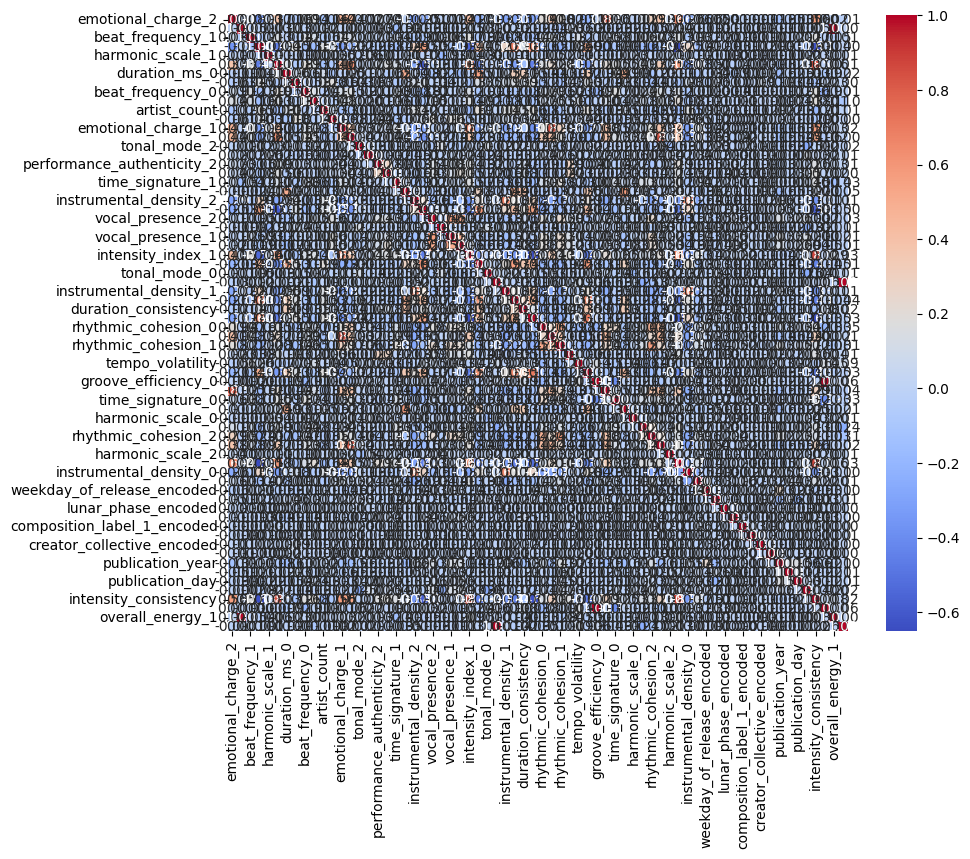

In [34]:
corr = train_df.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

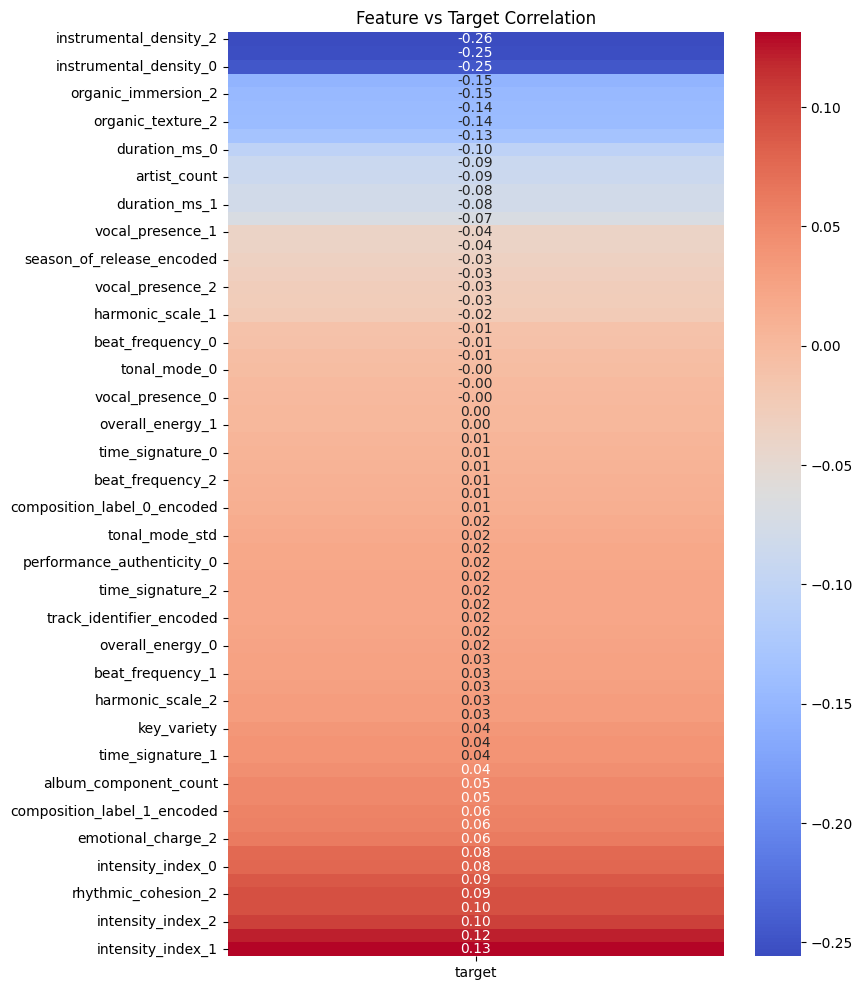

In [35]:
target_corr = corr["target"].drop("target").sort_values()
plt.figure(figsize=(8, 12))
sns.heatmap(target_corr.to_frame(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature vs Target Correlation")
plt.show()

In [36]:
features_to_drop = ['groove_efficiency_1', 'beat_frequency_1', 'intensity_index_0', 'groove_efficiency_2',
    'composition_label_0_encoded', 'time_signature_2', 'tonal_mode_1', 'publication_month',
    'harmonic_scale_0', 'tonal_mode_0', 'duration_ms_1', 'organic_texture_1']
train_df = train_df.drop(features_to_drop,axis=1)
test_df = test_df.drop(features_to_drop,axis=1)
#'organic_texture_1'

After dropping these features RMSE value of the RandomForestRegressor dropped.

In [37]:
X = train_df.drop(["target"],axis=1)
y = train_df["target"]

X_test = test_df

In [38]:
X.head()

,emotional_charge_2,organic_texture_2,harmonic_scale_1,duration_ms_0,album_name_length,beat_frequency_0,beat_frequency_2,artist_count,album_component_count,emotional_charge_1,...,composition_label_2_encoded,creator_collective_encoded,track_identifier_encoded,publication_year,publication_day,tonal_mode_std,intensity_consistency,overall_energy_0,overall_energy_1,overall_energy_2
0,0.482850,0.0201,1.0,154586.0,18.254362,95.992000,162.045,2.106971,6.0,0.640680,...,0.073138,0.000331,0.073488,2021,4,0.00000,0.714387,0.874715,0.815797,0.932214
1,0.267862,0.3340,6.0,46874.0,15.000000,148.076000,125.964,2.000000,3.0,0.255200,...,0.000010,0.000010,0.000010,2019,1,0.57735,0.737066,1.309921,0.955440,0.779448
2,0.242606,0.1110,4.0,264665.0,7.000000,124.738000,134.403,2.000000,14.0,0.456576,...,0.073138,0.000019,0.000029,2014,18,0.00000,0.711338,0.817735,0.978106,0.708921
3,0.426400,0.1960,5.0,209208.0,5.000000,119.117801,107.936,2.000000,15.0,0.518340,...,0.000010,0.173115,0.000010,2015,25,0.57735,0.773333,0.809162,0.910145,0.896143
4,0.000000,0.0811,6.0,215346.0,5.000000,118.006000,0.000,2.000000,17.0,0.611499,...,0.000351,0.000351,0.000360,2006,1,0.57735,0.551700,0.913612,0.849302,0.493700


# Model Selection

In [39]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth = 20,
        min_samples_split = 8,
        min_samples_leaf = 12,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=1000,
        max_depth=100,
        min_samples_split = 2,
        min_samples_leaf = 1,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": XGBRegressor(), 
    "KNearestNeighbor": KNeighborsRegressor()
    
}

In [40]:
X_train,X_val, y_train, y_val = train_test_split(
    X,y,
    test_size= 0.1,
    random_state = 42
)

In [41]:
results = {}
best_model = ''
best_rmse = float('inf')
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred)
    print(f"{name} is training")
    print(f"MAE: {mean_absolute_error(y_val, y_pred)}")
    print(f"RMSE: {rmse}")
    print(f"R2 Score: {r2_score(y_val, y_pred)} \n")

    if (rmse<best_rmse):
        best_model = name
        best_rmse = rmse

print(f'Best model is {best_model}')
print(f'Best RMSE Value: {best_rmse}')

Linear Regression is training
MAE: 15.89008442354499
RMSE: 19.57038634713408
R2 Score: 0.1725870709013405 

Decision Tree is training
MAE: 7.380942242625816
RMSE: 11.77477294067997
R2 Score: 0.7004780968888786 

Random Forest is training
MAE: 5.323551209219284
RMSE: 9.257796368759749
R2 Score: 0.8148435897944314 

Gradient Boosting is training
MAE: 8.888798688514479
RMSE: 11.612243002631981
R2 Score: 0.7086897706243445 

XGBoost is training
MAE: 6.571197032928467
RMSE: 9.773953437805176
R2 Score: 0.7936216592788696 

KNearestNeighbor is training
MAE: 8.89326408050641
RMSE: 15.612432046609472
R2 Score: 0.47341967716356115 

Best model is Random Forest
Best RMSE Value: 9.257796368759749


according to the above evaluation matrics Random Forest Regressor is the best model for this

In [42]:
model = models[best_model]
pred = model.predict(X_test)

pred_df = {
    "id": test_ids,
    "target": pred
}

pred_df = pd.DataFrame(pred_df)
pred_df.to_csv('submission.csv', index=False)